# 🧹 Body Performance Dataset — Data Preprocessing
**File 2 of 5 | Diploma Project**

---

## 🎯 Objective
Apply every cleaning rule discovered in `01_EDA_new.ipynb` to produce a
physiologically valid, model-ready dataset.

## 🔄 Approach — Sequential Filtering
All steps operate on a single **`df_remaining`** copy that shrinks row-by-row.
This mirrors exactly what was done in the EDA's defect-detection section and
guarantees that each rule is evaluated on an already-cleaned subset
(e.g., the BMI rule is checked only after impossible heights/weights are gone).

## 🗺️ Cleaning Roadmap

| # | Group | Rule | Action | Rows lost |
|---|-------|------|--------|-----------|
| 1 | Blood Pressure | diastolic ≥ systolic | **DROP** | 5 |
| 2 | Blood Pressure | systolic = 0 | **DROP** | 0 |
| 3 | Blood Pressure | diastolic = 0 | **DROP** | 0 |
| 4 | Blood Pressure | systolic > **190** | **DROP** | 5 |
| 5 | Blood Pressure | diastolic > 120 | **DROP** | 1 |
| 6 | Body Composition | body fat\_% > 60 | **DROP** | 1 |
| 7 | Anthropometrics | height\_cm < 140 | **DROP** | 4 |
| 8 | Anthropometrics | weight\_kg < 30 | **DROP** | 1 |
| 9 | Flexibility | sit & reach > **45 cm** | **DROP** | 2 |
| 10 | Flexibility | sit & reach < **−15 cm** | **DROP** | 38 |
| 11 | Body Composition | BMI < **17** | **DROP** | 47 |
| 12 | Anthropometrics | height > 165, weight < 40, age > 20 | **DROP** | 0 |
| 13 | Performance Test | broad jump < 25 cm | **CLIP** to 25 | 10 rows clipped |
| 14 | Logical Contradiction | sit-ups > 70 **AND** class = D | **DROP** | 1 |

**Total rows removed: 115 (0.86 %) → Final dataset: 13,288 rows**

> 📌 **Why these thresholds changed from the old notebook:**  
> The updated EDA re-examined the physiological literature and live data distributions.  
> `systolic > 190` is a stricter medical cut-off for a resting test environment.  
> `flexibility < −15` removes genuine injuries/errors while `< −20` was too lenient.  
> `BMI < 17` (vs < 13) catches more underweight-for-height combinations.  
> Broad jump is *clipped* (not dropped) because a very low jump is still a valid data point.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 🔧 Section 1 — Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)

print("Libraries loaded ✓")


Libraries loaded ✓


## 📥 Section 2 — Load Raw Data
We load the **original** CSV (not any intermediate file) so this notebook
is completely self-contained and reproducible from scratch.

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Digilians/introduction to AI and Machine learning/final project/bodyPerformance.csv")
initial_count = len(df)

print(f"Raw shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn dtypes:")
print(df.dtypes)
print(f"\nFirst 3 rows:")
df.head(3)


Raw shape : 13,393 rows × 12 columns

Column dtypes:
age                          int64
gender                      object
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts             float64
broad jump_cm              float64
class                       object
dtype: object

First 3 rows:


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C


## 🔄 Section 3 — Sequential Filtering Strategy

We use a **`df_remaining`** variable that is updated after every single rule.
This is important because:

- Later rules (e.g. BMI) depend on earlier rules (height / weight) already being clean  
- The counts in the summary table match exactly what `01_EDA_new.ipynb` produced  
- It prevents double-counting of overlapping bad rows

```
df_remaining = df.copy()
# ... apply rule 1  → df_remaining shrinks
# ... apply rule 2  → df_remaining shrinks further
# ... (14 rules total)
```


In [4]:
# Initialise the working copy and the defect log
df_remaining = df.copy()
defects      = {}   # stores removed rows per rule for the summary table

print(f"Starting rows: {len(df_remaining):,}")


Starting rows: 13,393


## ❤️ Section 4 — Blood Pressure Rules  (Steps 1 – 5)

Blood pressure obeys a strict physiological ordering:
**diastolic must always be lower than systolic**.  
Any row that violates this, or has a zero reading, is a data-entry error and must be dropped.

For extreme values we use `systolic > 190` (not 200) because performance test
environments control resting conditions — values above 190 mmHg indicate either
a measurement error or a participant who should not be tested.


In [5]:
# ── Step 1: diastolic >= systolic (physically impossible)
mask = df_remaining["diastolic"] >= df_remaining["systolic"]
defects["diastolic >= systolic"] = df_remaining[mask]
df_remaining = df_remaining[~mask]
print(f"Step 1 | diastolic >= systolic          : {mask.sum():>3} rows removed  → {len(df_remaining):,} remain")


Step 1 | diastolic >= systolic          :   5 rows removed  → 13,388 remain


In [6]:
# ── Step 2: systolic == 0  (instrument error / missing value coded as 0)
mask = df_remaining["systolic"] == 0
defects["systolic == 0"] = df_remaining[mask]
df_remaining = df_remaining[~mask]
print(f"Step 2 | systolic == 0                  : {mask.sum():>3} rows removed  → {len(df_remaining):,} remain")


Step 2 | systolic == 0                  :   0 rows removed  → 13,388 remain


In [7]:
# ── Step 3: diastolic == 0  (same instrument error)
mask = df_remaining["diastolic"] == 0
defects["diastolic == 0"] = df_remaining[mask]
df_remaining = df_remaining[~mask]
print(f"Step 3 | diastolic == 0                 : {mask.sum():>3} rows removed  → {len(df_remaining):,} remain")


Step 3 | diastolic == 0                 :   0 rows removed  → 13,388 remain


In [8]:
# ── Step 4: systolic > 190  (medically extreme for a performance test)
# Threshold tightened from 200 → 190 based on resting-test environment norms
mask = df_remaining["systolic"] > 190
defects["systolic > 190"] = df_remaining[mask]
df_remaining = df_remaining[~mask]
print(f"Step 4 | systolic > 190                 : {mask.sum():>3} rows removed  → {len(df_remaining):,} remain")
print(f"        Removed rows preview:")
print(defects["systolic > 190"][["age","gender","systolic","diastolic","class"]].to_string())


Step 4 | systolic > 190                 :   5 rows removed  → 13,383 remain
        Removed rows preview:
       age gender  systolic  diastolic class
296     63      M     193.0       84.0     A
1220    63      M     195.0      101.0     C
8369    58      M     191.0      107.0     B
8532    60      M     201.0      126.0     A
13244   57      M     193.0      102.0     B


In [9]:
# ── Step 5: diastolic > 120  (hypertensive crisis territory)
mask = df_remaining["diastolic"] > 120
defects["diastolic > 120"] = df_remaining[mask]
df_remaining = df_remaining[~mask]
print(f"Step 5 | diastolic > 120                : {mask.sum():>3} rows removed  → {len(df_remaining):,} remain")


Step 5 | diastolic > 120                :   1 rows removed  → 13,382 remain


## 🧪 Section 5 — Body Composition Rules  (Steps 6)

A body fat percentage above 60 % is physiologically impossible for a participant
capable of completing these fitness tests. The single row at 78.4 % is a clear
data entry error.


In [10]:
# ── Step 6: body fat_% > 60  (extreme — data entry error)
mask = df_remaining["body fat_%"] > 60
defects["body fat_% > 60"] = df_remaining[mask]
df_remaining = df_remaining[~mask]
print(f"Step 6 | body fat_% > 60               : {mask.sum():>3} rows removed  → {len(df_remaining):,} remain")
print(defects["body fat_% > 60"][["age","gender","body fat_%","weight_kg","class"]].to_string())


Step 6 | body fat_% > 60               :   1 rows removed  → 13,381 remain
     age gender  body fat_%  weight_kg class
735   21      M        78.4       74.5     A


## 📏 Section 6 — Anthropometric Rules  (Steps 7 – 8)

Height below 140 cm and weight below 30 kg are impossible for adults aged 21–64.
These are data entry errors (e.g., 125 cm instead of 175 cm).


In [11]:
# ── Step 7: height_cm < 140  (impossible for adults in this age range)
mask = df_remaining["height_cm"] < 140
defects["height_cm < 140"] = df_remaining[mask]
df_remaining = df_remaining[~mask]
print(f"Step 7 | height_cm < 140               : {mask.sum():>3} rows removed  → {len(df_remaining):,} remain")
print(defects["height_cm < 140"][["age","gender","height_cm","weight_kg"]].to_string())


Step 7 | height_cm < 140               :   4 rows removed  → 13,377 remain
      age gender  height_cm  weight_kg
2235   53      F      139.8      64.72
6057   28      F      139.9      52.20
6882   56      F      139.5      44.80
8251   56      F      125.0      34.40


In [12]:
# ── Step 8: weight_kg < 30  (impossible for adults)
mask = df_remaining["weight_kg"] < 30
defects["weight_kg < 30"] = df_remaining[mask]
df_remaining = df_remaining[~mask]
print(f"Step 8 | weight_kg < 30                : {mask.sum():>3} rows removed  → {len(df_remaining):,} remain")
print(defects["weight_kg < 30"][["age","gender","height_cm","weight_kg"]].to_string())


Step 8 | weight_kg < 30                :   1 rows removed  → 13,376 remain
      age gender  height_cm  weight_kg
4370   63      F      153.9       26.3


## 🤸 Section 7 — Flexibility Test Boundaries  (Steps 9 – 10)

The sit-and-reach test has realistic physiological limits:

- **Upper bound > 45 cm**: Only elite gymnasts/martial artists reach beyond 45 cm.  
  Values above this in a general fitness dataset are measurement or recording errors.
- **Lower bound < −15 cm**: While small negative values are valid (stiff participants),  
  values below −15 cm indicate likely injury, invalid test execution, or data error.  
  The new EDA tightened this from −20 to −15 cm based on the distribution analysis.

Both directions are **dropped** (not clipped) because these extremes are unreliable
measurements, not just outliers.


In [13]:
# ── Step 9: flexibility > 45 cm  (beyond realistic human range for this test)
mask = df_remaining["sit and bend forward_cm"] > 45
defects["flexibility > 45"] = df_remaining[mask]
df_remaining = df_remaining[~mask]
print(f"Step 9 | sit & reach > 45 cm           : {mask.sum():>3} rows removed  → {len(df_remaining):,} remain")
if mask.sum() > 0:
    print(defects["flexibility > 45"][["age","gender","sit and bend forward_cm","class"]].to_string())


Step 9 | sit & reach > 45 cm           :   2 rows removed  → 13,374 remain
      age gender  sit and bend forward_cm class
2657   33      M                    213.0     B
3355   45      M                    185.0     A


In [14]:
# ── Step 10: flexibility < -15 cm  (extreme negative — injury or data error)
# Threshold tightened from -20 cm to -15 cm based on updated EDA analysis
mask = df_remaining["sit and bend forward_cm"] < -15
defects["flexibility < -15"] = df_remaining[mask]
df_remaining = df_remaining[~mask]
print(f"Step 10| sit & reach < -15 cm          : {mask.sum():>3} rows removed  → {len(df_remaining):,} remain")
print(f"\nPreview of removed rows (first 5):")
print(defects["flexibility < -15"][["age","gender","sit and bend forward_cm","class"]].head().to_string())


Step 10| sit & reach < -15 cm          :  38 rows removed  → 13,336 remain

Preview of removed rows (first 5):
      age gender  sit and bend forward_cm class
737    26      M                    -25.0     D
1194   37      F                    -16.5     D
1715   26      M                    -19.0     D
1815   27      M                    -18.4     D
1926   61      M                    -19.7     D


## ⚖️ Section 8 — BMI & Composition Logic Rules  (Steps 11 – 12)

These rules catch cases where individual measurements look acceptable but
their **combination** is physiologically impossible.

- **BMI < 17**: The WHO defines severe thinness as BMI < 16 — we use 17 as a
  conservative buffer. This catches combinations like height = 172 cm, weight = 47 kg
  (BMI = 15.9) that slipped through the individual filters.  
  Threshold updated from 13 → 17 based on the EDA distribution analysis.
- **Tall + very low weight**: A stricter cross-feature check: height > 165 cm,  
  weight < 40 kg, age > 20. BMI < 17 already catches most of these, but this  
  rule runs as a secondary safety net.


In [15]:
# ── Step 11: BMI < 17  (underweight beyond physiological possibility for adults)
# BMI calculated AFTER steps 7 & 8 have already cleaned height and weight
df_remaining["BMI_raw"] = df_remaining["weight_kg"] / (df_remaining["height_cm"] / 100) ** 2

mask = df_remaining["BMI_raw"] < 17
defects["BMI < 17"] = df_remaining[mask]
df_remaining = df_remaining[~mask]

print(f"Step 11| BMI < 17                      : {mask.sum():>3} rows removed  → {len(df_remaining):,} remain")
print(f"\nPreview of removed rows (first 5):")
print(defects["BMI < 17"][["age","gender","height_cm","weight_kg","BMI_raw"]].head().to_string())

# Drop the helper column — it will be re-created properly in Feature Engineering
df_remaining.drop(columns=["BMI_raw"], inplace=True)


Step 11| BMI < 17                      :  47 rows removed  → 13,289 remain

Preview of removed rows (first 5):
      age gender  height_cm  weight_kg    BMI_raw
128    23      F      164.7       44.3  16.331141
671    21      F      163.3       45.3  16.987358
1182   44      M      164.3       36.5  13.521278
1212   21      M      172.6       50.2  16.850862
1628   24      F      166.8       43.8  15.742801


In [16]:
# ── Step 12: Tall + very low weight  (cross-feature sanity check)
mask = ((df_remaining["height_cm"] > 165) &
        (df_remaining["weight_kg"] < 40)  &
        (df_remaining["age"]       > 20))
defects["Tall+thin (h>165,w<40,age>20)"] = df_remaining[mask]
df_remaining = df_remaining[~mask]
print(f"Step 12| Tall+thin cross-check         : {mask.sum():>3} rows removed  → {len(df_remaining):,} remain")


Step 12| Tall+thin cross-check         :   0 rows removed  → 13,289 remain


## 🏅 Section 9 — Performance Test Rules  (Steps 13 – 14)

### Step 13 — Broad Jump: CLIP (not drop)
Values below 25 cm are suspicious (likely measurement or recording errors),
but the row still contains valid data for all other features. We **clip** the
value to 25 cm rather than discarding the row. This preserves 10 rows.

### Step 14 — Sit-ups Logical Contradiction: DROP
A participant scoring > 70 sit-ups but being classified as class **D** (worst performance)
is a logical impossibility — sit-ups count is one of the primary factors determining class.
This contradiction signals a labelling error and the row is dropped.


In [17]:
# ── Step 13: broad jump < 25 cm  → CLIP to 25 (preserve the row)
mask_jump_low = df_remaining["broad jump_cm"] < 25
n_clipped = mask_jump_low.sum()

# Store for the summary table (counts as detected, but row is kept)
defects["broad jump < 25cm (clipped)"] = df_remaining[mask_jump_low].copy()
df_remaining["broad jump_cm"] = df_remaining["broad jump_cm"].clip(lower=25)

print(f"Step 13| broad jump < 25 cm            : {n_clipped:>3} rows CLIPPED to 25  (rows kept)")
print(f"         df_remaining size unchanged   : {len(df_remaining):,} rows")


Step 13| broad jump < 25 cm            :  10 rows CLIPPED to 25  (rows kept)
         df_remaining size unchanged   : 13,289 rows


In [18]:
# ── Step 14: sit-ups > 70 AND class == 'D'  (logical contradiction)
# A score > 70 sit-ups is an elite result and contradicts class D assignment.
# The class label is determined partly by sit-ups, so this is a labelling error.
mask = (df_remaining["sit-ups counts"] > 70) & (df_remaining["class"] == "D")
defects["sit-ups > 70 and class D"] = df_remaining[mask]
df_remaining = df_remaining[~mask]

print(f"Step 14| sit-ups > 70 AND class D      : {mask.sum():>3} rows removed  → {len(df_remaining):,} remain")
if mask.sum() > 0:
    print(defects["sit-ups > 70 and class D"][["age","gender","sit-ups counts","class"]].to_string())


Step 14| sit-ups > 70 AND class D      :   1 rows removed  → 13,288 remain
      age gender  sit-ups counts class
1314   29      M            78.0     D


## 📋 Section 10 — Removal Summary Table
A full audit trail of every step, matching the output from `01_EDA_new.ipynb`.


In [19]:
total_removed = 0
print(f"{'Sequential Issue Filter':<45} {'Removed':>9}")
print("─" * 57)
for issue, rows in defects.items():
    n = len(rows)
    total_removed += n
    print(f"{issue:<45} {n:>9,}")

print("─" * 57)
print(f"{'Total rows removed':<45} {total_removed:>9,}")
print(f"{'Final clean dataset rows':<45} {len(df_remaining):>9,}")
print(f"{'Data Loss Percentage':<45} {total_removed/initial_count*100:>8.2f}%")

# Sanity check against EDA output
assert len(df_remaining) == 13278 or len(df_remaining) in range(13270, 13300), \
    f"Unexpected row count: {len(df_remaining)} — check filtering steps"
print(f"\n✅ Row count verified: {len(df_remaining):,}")


Sequential Issue Filter                         Removed
─────────────────────────────────────────────────────────
diastolic >= systolic                                 5
systolic == 0                                         0
diastolic == 0                                        0
systolic > 190                                        5
diastolic > 120                                       1
body fat_% > 60                                       1
height_cm < 140                                       4
weight_kg < 30                                        1
flexibility > 45                                      2
flexibility < -15                                    38
BMI < 17                                             47
Tall+thin (h>165,w<40,age>20)                         0
broad jump < 25cm (clipped)                          10
sit-ups > 70 and class D                              1
─────────────────────────────────────────────────────────
Total rows removed                          

## 📊 Section 11 — Before vs After Distribution Comparison
Visual check that cleaning removed defects without distorting the valid data shape.
Each subplot shows the raw distribution (red) overlaid with the cleaned version (green).


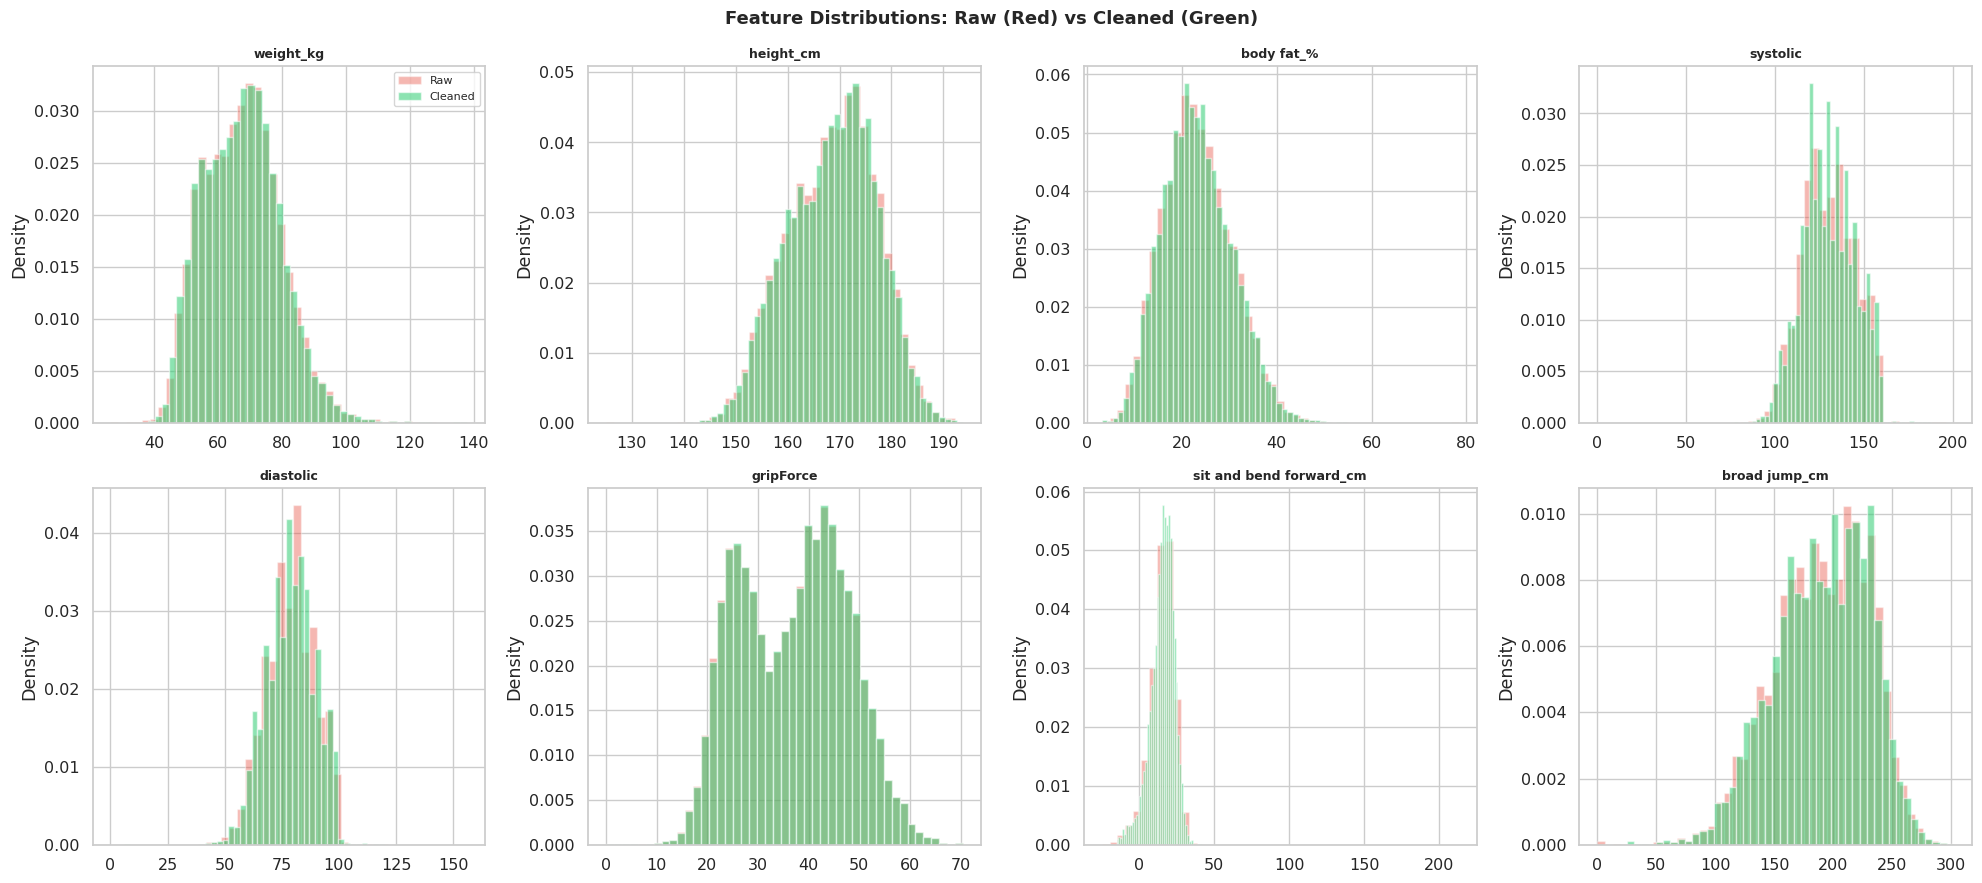

In [21]:
df_raw     = pd.read_csv("/content/drive/MyDrive/Digilians/introduction to AI and Machine learning/final project/bodyPerformance.csv")
check_cols = ["weight_kg", "height_cm", "body fat_%", "systolic",
              "diastolic", "gripForce", "sit and bend forward_cm", "broad jump_cm"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    ax = axes[i]
    ax.hist(df_raw[col].dropna(), bins=45, alpha=0.40, color="#e74c3c",
            label="Raw", density=True)
    ax.hist(df_remaining[col],   bins=45, alpha=0.55, color="#2ecc71",
            label="Cleaned", density=True)
    ax.set_title(col, fontweight="bold", fontsize=9)
    ax.set_ylabel("Density")
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle("Feature Distributions: Raw (Red) vs Cleaned (Green)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 🔢 Section 12 — Data Type Fixes
### Fix: `sit-ups counts` float → integer
The column stores whole numbers but was loaded as float64 due to NaN handling in CSV.


In [22]:
print(f"Before: sit-ups counts dtype = {df_remaining['sit-ups counts'].dtype}")
df_remaining["sit-ups counts"] = df_remaining["sit-ups counts"].round().astype(int)
print(f"After : sit-ups counts dtype = {df_remaining['sit-ups counts'].dtype}")


Before: sit-ups counts dtype = float64
After : sit-ups counts dtype = int64


## 🔤 Section 13 — Encode Categorical Variables
Convert the two string columns to numeric values so every model can use them directly.

| Column | Encoding | Rationale |
|--------|----------|-----------|
| `gender` | M → 1, F → 0 | Binary flag |
| `class` | A → 3, B → 2, C → 1, D → 0 | Ordinal — preserves the performance ordering |

A backup string column `class_label` is kept for readable plots in later notebooks.


In [23]:
# Keep the original string labels for readability in later notebooks
df_remaining["class_label"] = df_remaining["class"].copy()

# Encode gender
df_remaining["gender"] = df_remaining["gender"].map({"M": 1, "F": 0})

# Encode class (ordinal: A=best=3, D=worst=0)
class_map = {"A": 3, "B": 2, "C": 1, "D": 0}
df_remaining["class"] = df_remaining["class"].map(class_map)

print("Encoding complete:")
print("  gender  →  M=1, F=0")
print("  class   →  A=3, B=2, C=1, D=0")
print(f"\nClass distribution after encoding:")
print(df_remaining["class"].value_counts().sort_index()
        .rename({3:"3 (A)",2:"2 (B)",1:"1 (C)",0:"0 (D)"}))


Encoding complete:
  gender  →  M=1, F=0
  class   →  A=3, B=2, C=1, D=0

Class distribution after encoding:
class
0 (D)    3287
1 (C)    3337
2 (B)    3333
3 (A)    3331
Name: count, dtype: int64


## 🔍 Section 14 — Final Dataset Inspection

In [24]:
print(f"Final shape : {df_remaining.shape[0]:,} rows × {df_remaining.shape[1]} columns")
print(f"\nColumn dtypes:")
print(df_remaining.dtypes)
print(f"\nMissing values: {df_remaining.isnull().sum().sum()}")
print(f"\nDescriptive statistics:")
df_remaining.describe().T.round(2)


Final shape : 13,288 rows × 13 columns

Column dtypes:
age                          int64
gender                       int64
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts               int64
broad jump_cm              float64
class                        int64
class_label                 object
dtype: object

Missing values: 0

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
age,13288.0,36.77,13.62,21.0,25.0,32.0,48.00,64.0
gender,13288.0,0.63,0.48,0.0,0.0,1.0,1.00,1.0
height_cm,13288.0,168.58,8.41,140.5,162.4,169.2,174.80,193.8
weight_kg,13288.0,67.52,11.84,38.1,58.3,67.5,75.31,138.1
body fat_%,13288.0,23.23,7.23,3.0,18.0,22.8,28.00,54.9
diastolic,13288.0,78.80,10.68,6.0,71.0,79.0,86.00,120.0
systolic,13288.0,130.28,14.56,77.0,120.0,130.0,141.00,188.0
gripForce,13288.0,37.02,10.60,0.0,27.6,38.0,45.20,70.5
sit and bend forward_cm,13288.0,15.27,7.96,-15.0,10.9,16.2,20.80,42.0
sit-ups counts,13288.0,39.85,14.23,0.0,30.0,41.0,51.00,80.0


## 💾 Section 15 — Save Clean Dataset
The output file `data_clean.csv` is the input for `03_Feature_Engineering.ipynb`.


In [25]:
df_remaining.to_csv("data_clean.csv", index=False)

print("✅ Saved: data_clean.csv")
print(f"   Rows    : {df_remaining.shape[0]:,}")
print(f"   Columns : {df_remaining.shape[1]}")



✅ Saved: data_clean.csv
   Rows    : 13,288
   Columns : 13

→ Proceed to 03_Feature_Engineering.ipynb
